In [ ]:
import yfinance as yf  # library for pulling stock/ETF data from Yahoo Finance. API wrapper
import pandas as pd  # DataFrame library used to hold and manipulate the pulled data
import seaborn as sns  # statistical plotting library (imported here, used later for styling)
import matplotlib.pyplot as plt  # core plotting library for the charts below

ticker = yf.Ticker('SPY')  # create a yfinance Ticker object for the S&P 500 ETF
ticker.history(period = 'max')  # pull SPY's full available price history (quick check, not stored)
ticker.funds_data.description  # print SPY's long-form fund description text

Research Question/Problem Definition
 - This project aims to track the 11 sectors that make up the S&P 500, by graphing the sector ETFs that track those industries and using the S&P 500 as a benchmark. So my question is: How did the 11 sector ETFS perform against eachother the first 8 months of the year compared to the S&P 500 and what was the best performing ETF?

Data Description
I used the yfinance library (a wrapper API for Yahoo Finance), to pull my data. It uses the 11 sector ETFs to pull it's data. Those tickers are: XLK, XLF, XLV, XLE, XLI, XLC, XLY, XLP, XLB, XLRE, and XLU. It also uses the S&P 500. Each row is a trading day and I pulled the closing price for the ticker symbols. YTD return means the percent gain/ loss from jan to sept. Cumalitive Growth means the growth that whole time up until then. The data set covers all of the trading days from jan 1 to sept 1 for 12 tickers.

[                       0%                       ]

Fetching current year-to-date market data...


[*********************100%***********************]  12 of 12 completed


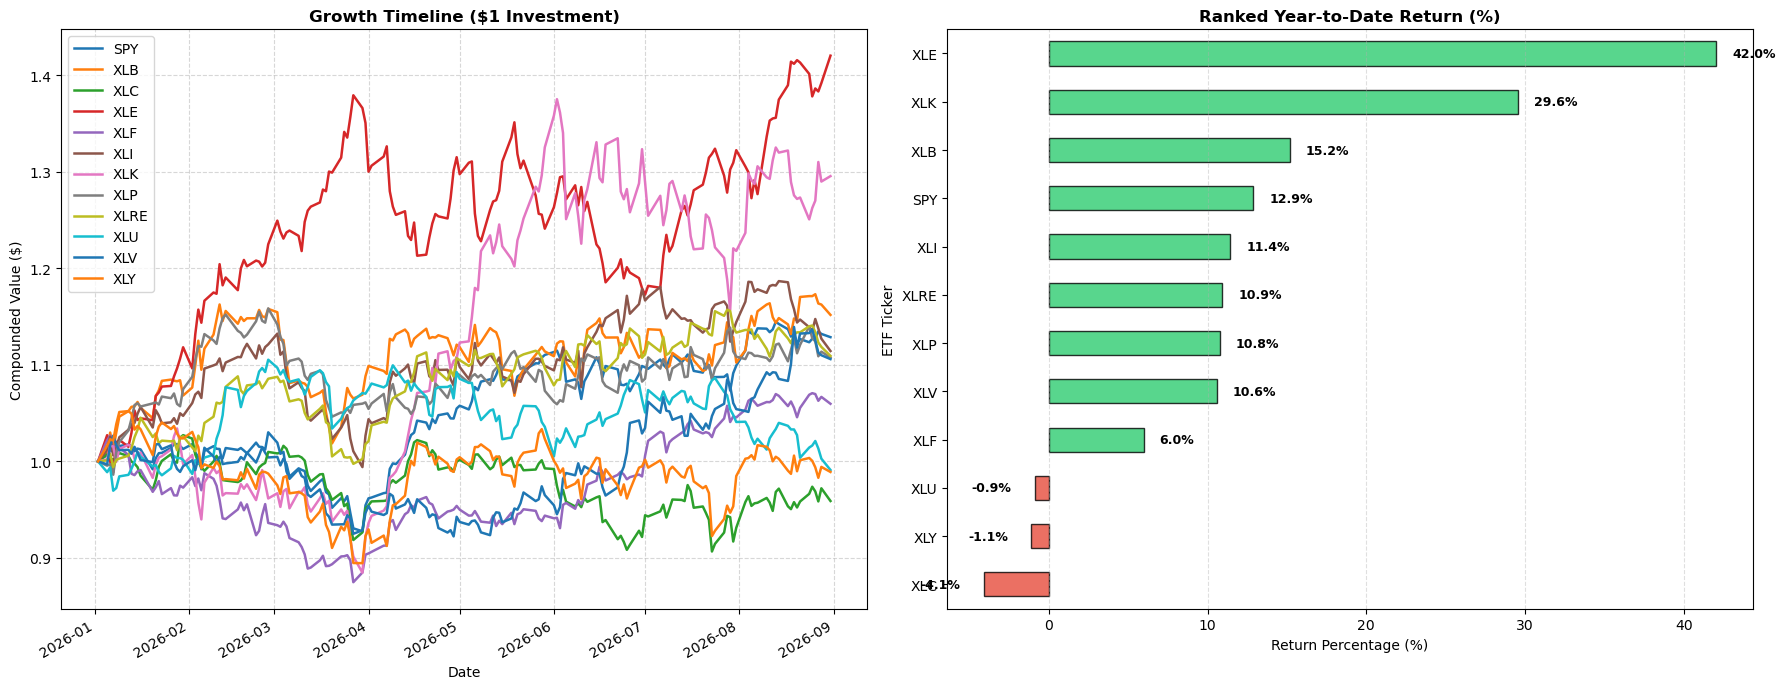

In [ ]:
# 1. Store the 11 sector etfs in a list called "tickers". Also add in SPY for benchmarking
tickers = ['XLK', 'XLF', 'XLV', 'XLE', 'XLI', 'XLC', 'XLY', 'XLP', 'XLB', 'XLRE', 'XLU', 'SPY']  

# 2. Download Year-to-Date data (Starting Jan 1st of the current year)
print("Fetching current year-to-date market data...")  # progress message while the download runs
#https://ranaroussi.github.io/yfinance/reference/api/yfinance.download.html#yfinance.download
#reference for download function
#yf.download returns a pandas dataframe
data = yf.download(tickers, start="2026-01-01", end="2026-09-01")['Close']  # pull daily data for all tickers, keep only the Close price column

# 3. Process data using the cumprod pipeline
#panda documentation
daily_returns = data.pct_change()  # day-over-day percent change for each ticker
growth_multipliers = daily_returns.fillna(0) + 1  # turn each day's % change into a multiplier (0% -> 1.0x), filling the first NaN day with 0% change
cumulative_growth = growth_multipliers.cumprod()  # running product of daily multipliers = value of $1 invested at the start

# 4. Calculate Final YTD Return Percentage
# We take the last row of cumulative growth, subtract 1, and multiply by 100
final_ytd_returns = (cumulative_growth.iloc[-1] - 1) * 100  # convert the final cumulative growth value into a YTD % return

# Sort the returns for a much cleaner leaderboard bar chart
final_ytd_returns_sorted = final_ytd_returns.sort_values(ascending=True)  # smallest to largest, so the bar chart reads as a ranked leaderboard

# 5. Create a 1-row, 2-column layout figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))  # one figure, two side-by-side subplots

# --- LEFT CHART: Cumulative Growth Line Graph ---
cumulative_growth.plot(ax=ax1, linewidth=1.8)  # one line per ticker showing $1 growth over time
ax1.set_title("Growth Timeline ($1 Investment)", fontsize=12, fontweight='bold')  # chart title
ax1.set_ylabel("Compounded Value ($)")  # y-axis label
ax1.set_xlabel("Date")  # x-axis label
ax1.grid(True, linestyle="--", alpha=0.5)  # light dashed gridlines for readability
ax1.legend(loc="upper left")  # show which line belongs to which ticker

# --- RIGHT CHART: Sorted YTD Return Bar Chart ---
# Use conditional colors: Green for positive return, Red for negative return
colors = ['#2ecc71' if x >= 0 else '#e74c3c' for x in final_ytd_returns_sorted]  # green for gainers, red for losers

final_ytd_returns_sorted.plot(kind='barh', ax=ax2, color=colors, edgecolor='black', alpha=0.8)  # horizontal bar chart of sorted returns
ax2.set_title("Ranked Year-to-Date Return (%)", fontsize=12, fontweight='bold')  # chart title
ax2.set_xlabel("Return Percentage (%)")  # x-axis label
ax2.set_ylabel("ETF Ticker")  # y-axis label
ax2.grid(True, linestyle="--", alpha=0.4, axis='x')  # light vertical gridlines only

# Add exact value labels on top of each bar for scannability
for index, value in enumerate(final_ytd_returns_sorted):  # walk through each ticker's sorted return value
    ax2.text(value + (1 if value >= 0 else -4), index, f"{value:.1f}%",  # place the % label just past the end of its bar
             va='center', fontsize=9, fontweight='bold')  # vertically centered, bold text

plt.tight_layout()  # remove overlapping/clipped labels between the two subplots
plt.show()  # render the figure

Data Cleaning Commentary
I changed the data for the first trading day this year to 0 and the ticker symbols dollar value are normalized to $1. This is because I needed to get all of the ticker symbols to track off of the same number. If I let them start off at their ticker price from the beginning of the year, it would look as those a stock priced at $200 and one at $100 would have wildley different graphs, so to get everything clean on the same graph it's set down to that. 

Visualization Description
This graph tracks each sector performance starting from $1. The X axes are all of the dates from Jan 1st 2026 to September 1st 2026. The Y axes is the percentage change. There's a colored legend to make the reading a little easier for the graph. On the bar graph, I decided to make a bar graph to just make it easier to see the percentage chain through the year for the different sectors. They're ranked from best to wrost performance, and offer a different way to look at the data

Ethics and Limitations
This project had a lot of limitations. With so many resources out there, I really had to limit things to what I could understand or explain to others easily. For example, I really wanted to create an AI chatbot for this project, and I was able to do so. With that, Claude initially wanted to use a vector data base for my "RAG" system, but I don't understand those yet. I settled for passing in the entire data table, system prompt, plus chat history to Claudes API for every message request. That I could understand. I also capped the API token usage, so that my cost wouldn't run up and I got a temporary API key incase my key got leaked or if someone ran up my token cost. For the data itself, it only covers the first 8 months of the year, and it's hard to make financial decisions without years of data. The graph also only uses the closing prices and not intra day prices. Also ETFS get changed around all the time, so performance can vary as weights within a sector can change all the time. Much of what goes into making stock decisions is not covered within the scope of this project. In the future I woud like to explore more data and AI with a full RAG system I can understand and more math that goes into portfolio optomization.

Code and AI Transparency
My data is pulled from Yfinance. I did use claude to help me implement features and to clean up my code. Things like .pct_change(), cumprod(), .fillna(). As well as using the Claude API. I do have a conceptual and written understanding of what I wanted to do. My reasearch question and data I wanted to use were my idea. I limited my AI usage within the scope of what I could understand and explain to others. Not doing so would have resulted in a project that I did not understand nor have the capability of explaining to others or fixing if someone went wrong. APA-Style Sources: Sipilä, L. (2023). Sector performance analysis through the comparison of SPDR ETFs and the S&P 500 index from 2007 to 2022, Yuvzhenko, D., Putrenko, V., Lupenko, S., & Pashynska, N. (2025). Scalable Multimodal RAG Systems: Integrating AI for Adaptive Information Retrieval and Generation. In IWSCI@ IntSol (pp. 164-176), Markowitz, H. M. (1990). Foundations of portfolio theory. Harry Markowitz: Selected Works, S, 481-490.

In [ ]:
etf_context_text = "ETF Performance Data:\n"  # this string will hold all of our ETF information as plain text

for tkr in tickers:  # go through each ticker symbol in our list, one at a time
    ytd = round(final_ytd_returns_sorted[tkr], 2)  # look up this ticker's year-to-date percent return, rounded to 2 decimals
    end_value = round(cumulative_growth[tkr].iloc[-1], 2)  # look up what $1 invested in this ticker grew to
    line = tkr + ": YTD return " + str(ytd) + "%, $1 invested grew to $" + str(end_value) + "\n"  # build one line of plain text
    etf_context_text = etf_context_text + line  # add this new line onto the end of our big string

print(etf_context_text)  # print out the finished text so we can see what we built

In [ ]:
import anthropic  # this is the package that lets our code talk to Claude
from dotenv import load_dotenv  # this package can read secret values from a .env file

load_dotenv()  # load our secret API key from the .env file so our code can use it
claude = anthropic.Anthropic()  # create a "client" - an object that knows how to send messages to Claude

instructions = "You are a financial assistant. Answer questions using ONLY the ETF performance data below. If the data does not contain the answer, say so instead of guessing."  # tell Claude how to behave
system_prompt = instructions + "\n\n" + etf_context_text  # combine our instructions with all of our ETF data into one big string

conversation = []  # an empty list that will store every question and answer we make

print("Ask about the ETFs above. Type 'exit' or 'quit' to stop.\n")  # print instructions for the user

while True:  # loop forever until we say "break" below
    question = input("You: ")  # ask the user to type a question
    question = question.strip()  # remove any extra spaces at the start or end
    question_lower = question.lower()  # make a lowercase copy so "Exit" and "exit" both work

    if question_lower == "exit" or question_lower == "quit":  # check if the user wants to stop
        print("Ending chat.")
        break  # this stops the while loop

    if question == "":  # if the user typed nothing and just pressed enter
        continue  # skip everything below and go back to the top of the loop

    conversation.append({"role": "user", "content": question})  # add the question to our list of messages

    response = claude.messages.create(
        model="claude-opus-5",  # tells Claude which version of itself to use
        max_tokens=2048,  # the most words/pieces Claude is allowed to reply with
        system=system_prompt,  # our instructions and data, sent with every question
        messages=conversation,  # the full list of questions and answers so far
    )

    answer = ""  # this will hold Claude's answer as one string of text
    for block in response.content:  # Claude's reply comes back broken into pieces called "blocks"
        if block.type == "text":  # we only want the pieces that are plain text
            answer = answer + block.text  # add this piece onto our answer

    print("Claude: " + answer + "\n")  # print Claude's full answer

    conversation.append({"role": "assistant", "content": answer})  # add Claude's answer to our list of messages